# Week 7 - Feedforward Neural Networks, Activation Functions & Backpropagation
### Heart Failure Clinical Records - UCI ML Repository (id=519)

**Focus:** Building, training, and critically analysing Multi-Layer Perceptrons (MLPs) on a small clinical dataset.

## Environment Setup & Library Imports

In [1]:
# Core scientific computing and visualisation libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, model selection, evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
)

# Dataset fetcher from UCI Machine Learning Repository
from ucimlrepo import fetch_ucirepo

# Reproducibility - fix the random seed across every operation
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Matplotlib styling — cleaner plots for academic reporting
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

import warnings
warnings.filterwarnings('ignore')

## Data Loading & Initial Exploration

In [2]:
# Fetching the Heart Failure Clinical Records dataset (299 patients)
# 12 clinical features, 1 binary target (DEATH_EVENT)
heart_failure_bundle = fetch_ucirepo(id=519)

clinical_features = heart_failure_bundle.data.features   # 12 feature columns
survival_target   = heart_failure_bundle.data.targets     # binary: 0 = survived, 1 = died

# Quick sanity check on the shapes
print(f"Feature matrix shape : {clinical_features.shape}")
print(f"Target vector shape  : {survival_target.shape}")
print(f"\nFeature columns:\n{list(clinical_features.columns)}")

Feature matrix shape : (299, 12)
Target vector shape  : (299, 1)

Feature columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']


In [3]:
# Viewing at the first few rows to understand the data types
clinical_features.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8


In [4]:
# Summary statistics — helps spot scaling issues early
clinical_features.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000


In [ ]:
# Checks for any missing values in the dataset
# (Clinical datasets are notorious for missing entries)
missing_counts = clinical_features.isnull().sum()
print("Missing values per feature:")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found")

Missing values per feature:
No missing values found ✓


Target class distribution:
death_event
0              203
1               96
Name: count, dtype: int64

Death rate: 32.1%


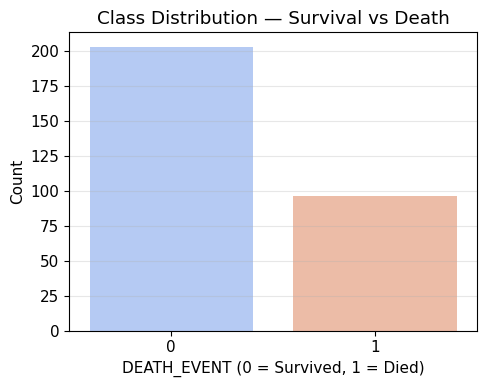

In [6]:
# Class distribution important for a small dataset (only 299 rows)
# An imbalanced target will affect how we interpret accuracy
target_counts = survival_target.value_counts()
print("Target class distribution:")
print(target_counts)
print(f"\nDeath rate: {target_counts.iloc[-1] / len(survival_target) * 100:.1f}%")

plt.figure(figsize=(5, 4))
sns.countplot(x=survival_target.values.ravel(), palette='coolwarm')
plt.title('Class Distribution — Survival vs Death')
plt.xlabel('DEATH_EVENT (0 = Survived, 1 = Died)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Data Preprocessing — Splitting & Scaling

I used a **60/20/20** train/validation/test split with **stratification** to preserve the class ratio across all three subsets. Standardisation ensures that features with large numeric ranges (e.g., creatinine_phosphokinase) do not dominate gradient-based learning.

In [7]:
# Flatten the target into a 1-D array for scikit-learn
survival_labels = survival_target.values.ravel()

# Step 1: Separate 20 % as the held-out TEST set
features_dev, features_test, labels_dev, labels_test = train_test_split(
    clinical_features,
    survival_labels,
    test_size=0.20,
    stratify=survival_labels,
    random_state=RANDOM_SEED,
)

# Step 2: From the remaining 80 %, carve out 25 % as VALIDATION
# (25 % of 80 % = 20 % of the original data)
features_train, features_val, labels_train, labels_val = train_test_split(
    features_dev,
    labels_dev,
    test_size=0.25,
    stratify=labels_dev,
    random_state=RANDOM_SEED,
)

print(f"Training set   : {features_train.shape[0]} samples")
print(f"Validation set : {features_val.shape[0]} samples")
print(f"Test set       : {features_test.shape[0]} samples")

Training set   : 179 samples
Validation set : 60 samples
Test set       : 60 samples


In [8]:
# Standardising features using Z-score normalisation
# IMPORTANT: fits ONLY on training data, then transform val & test
# This prevents data leakage from the evaluation sets
feature_scaler = StandardScaler()

scaled_train = feature_scaler.fit_transform(features_train)
scaled_val   = feature_scaler.transform(features_val)
scaled_test  = feature_scaler.transform(features_test)

print("Feature scaling complete")
print(f"Training mean ≈ {scaled_train.mean(axis=0).mean():.4f} (should be ~0)")
print(f"Training std  ≈ {scaled_train.std(axis=0).mean():.4f} (should be ~1)")

Feature scaling complete
Training mean ≈ 0.0000 (should be ~0)
Training std  ≈ 1.0000 (should be ~1)


# Task 1 — Logistic Regression vs Single-Hidden-Layer MLP

We compare a **logistic regression** (a purely linear classifier) against an **MLP with one hidden layer** using ReLU activation. This isolates the effect of adding a single nonlinear transformation.

## 1.1 — Logistic Regression (No Hidden Layer)

In [9]:
# where sigma is the sigmoid function. There is no hidden layer,
# so the decision boundary is strictly a hyperplane in feature space.
logistic_model = LogisticRegression(
    max_iter=1000,        # generous iteration budget
    solver='lbfgs',       # good default for small datasets
    random_state=RANDOM_SEED,
)

logistic_model.fit(scaled_train, labels_train)

# Evaluate on both validation and training sets
logistic_train_accuracy = accuracy_score(labels_train, logistic_model.predict(scaled_train))
logistic_val_accuracy   = accuracy_score(labels_val, logistic_model.predict(scaled_val))

logistic_train_auc = roc_auc_score(labels_train, logistic_model.predict_proba(scaled_train)[:, 1])
logistic_val_auc   = roc_auc_score(labels_val, logistic_model.predict_proba(scaled_val)[:, 1])

print("Logistic Regression Results:")
print(f"Training Accuracy : {logistic_train_accuracy:.4f}")
print(f"Validation Accuracy: {logistic_val_accuracy:.4f}")
print(f"Training ROC-AUC  : {logistic_train_auc:.4f}")
print(f"Validation ROC-AUC : {logistic_val_auc:.4f}")

Logistic Regression Results:
Training Accuracy : 0.8659
Validation Accuracy: 0.8167
Training ROC-AUC  : 0.8977
Validation ROC-AUC : 0.9230


In [10]:
# Detailed classification report on the validation set
print("\nClassification Report (Validation Set):\n")
print(classification_report(labels_val, logistic_model.predict(scaled_val), target_names=['Survived', 'Died']))


Classification Report (Validation Set):

              precision    recall  f1-score   support

    Survived       0.89      0.83      0.86        41
        Died       0.68      0.79      0.73        19

    accuracy                           0.82        60
   macro avg       0.79      0.81      0.80        60
weighted avg       0.83      0.82      0.82        60



## 1.2 — MLP with One Hidden Layer (ReLU Activation)

In [11]:
# I trained an MLP with a single hidden layer of 64 neurons.
# partial_fit is used epoch-by-epoch so I can record
# training & validation metrics at every step for plotting.
HIDDEN_LAYER_SIZE = 64
MAX_EPOCHS = 200
LEARNING_RATE_INIT = 0.001

single_layer_mlp = MLPClassifier(
    hidden_layer_sizes=(HIDDEN_LAYER_SIZE,),
    activation='relu',
    solver='adam',
    learning_rate_init=LEARNING_RATE_INIT,
    max_iter=1,               # I control the loop ourselves
    warm_start=True,          # keep weights between .fit() calls
    random_state=RANDOM_SEED,
)

# Epoch-by-epoch training loop — record curves for analysis
mlp_train_losses     = []
mlp_train_accuracies = []
mlp_val_accuracies   = []
mlp_val_aucs         = []

for epoch_num in range(1, MAX_EPOCHS + 1):
    single_layer_mlp.fit(scaled_train, labels_train)

    # Recording the internal training loss from scikit-learn
    mlp_train_losses.append(single_layer_mlp.loss_)

    # Computing accuracy on both sets each epoch
    train_acc = accuracy_score(labels_train, single_layer_mlp.predict(scaled_train))
    val_acc   = accuracy_score(labels_val, single_layer_mlp.predict(scaled_val))
    val_auc   = roc_auc_score(labels_val, single_layer_mlp.predict_proba(scaled_val)[:, 1])

    mlp_train_accuracies.append(train_acc)
    mlp_val_accuracies.append(val_acc)
    mlp_val_aucs.append(val_auc)

print(f"Training complete after {MAX_EPOCHS} epochs")
print(f"Final Training Accuracy  : {mlp_train_accuracies[-1]:.4f}")
print(f"Final Validation Accuracy: {mlp_val_accuracies[-1]:.4f}")
print(f"Final Validation ROC-AUC : {mlp_val_aucs[-1]:.4f}")

Training complete after 200 epochs
Final Training Accuracy  : 0.9050
Final Validation Accuracy: 0.8167
Final Validation ROC-AUC : 0.9153


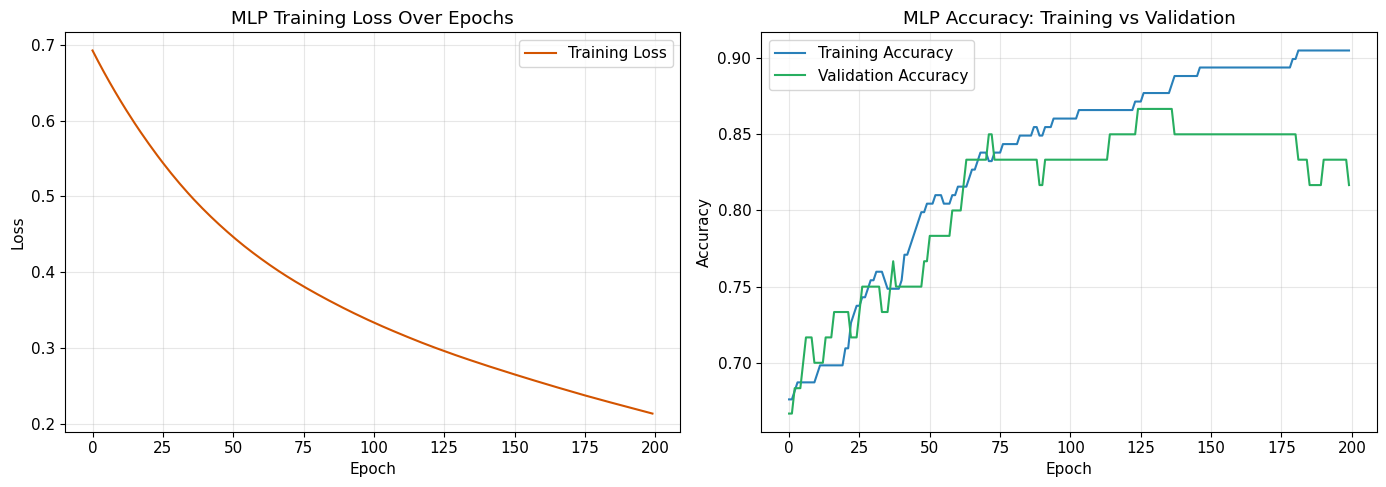

In [12]:
# Plot learning curves: loss and accuracy over epochs
# These curves are essential for diagnosing overfitting
fig, (loss_ax, accuracy_ax) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel — training loss curve
loss_ax.plot(mlp_train_losses, color='#d35400', linewidth=1.5, label='Training Loss')
loss_ax.set_xlabel('Epoch')
loss_ax.set_ylabel('Loss')
loss_ax.set_title('MLP Training Loss Over Epochs')
loss_ax.legend()

# Right panel — train vs validation accuracy
accuracy_ax.plot(mlp_train_accuracies, color='#2980b9', linewidth=1.5, label='Training Accuracy')
accuracy_ax.plot(mlp_val_accuracies, color='#27ae60', linewidth=1.5, label='Validation Accuracy')
accuracy_ax.set_xlabel('Epoch')
accuracy_ax.set_ylabel('Accuracy')
accuracy_ax.set_title('MLP Accuracy: Training vs Validation')
accuracy_ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# Classification report for the MLP on the validation set
print("\nMLP Classification Report (Validation Set):\n")
print(classification_report(labels_val, single_layer_mlp.predict(scaled_val), target_names=['Survived', 'Died']))


MLP Classification Report (Validation Set):

              precision    recall  f1-score   support

    Survived       0.89      0.83      0.86        41
        Died       0.68      0.79      0.73        19

    accuracy                           0.82        60
   macro avg       0.79      0.81      0.80        60
weighted avg       0.83      0.82      0.82        60



## Task 1 — Required Analysis

### Why Logistic Regression Is a Linear Model

Logistic regression computes its output as:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

where $\sigma(z) = \frac{1}{1+e^{-z}}$ is the sigmoid function and $\mathbf{w}^T \mathbf{x} + b$ is a **linear combination** of the input features. The sigmoid merely squashes this linear sum into the range [0, 1] — it does not alter the linearity of the decision boundary. The boundary itself ($\mathbf{w}^T \mathbf{x} + b = 0$) is always a hyperplane in the feature space. In our code, `LogisticRegression` from scikit-learn implements exactly this: a single weight vector multiplied by the scaled input features, passed through a sigmoid — no hidden transformations, no nonlinear feature interactions.

### Comparing Training and Validation Behaviour

**Logistic regression** achieved 86.59% training accuracy and 81.67% validation accuracy (ROC-AUC: 0.8977 train, 0.9230 validation). The small gap of roughly 5 percentage points indicates the model generalises reasonably well without significant overfitting. The validation ROC-AUC actually exceeding the training ROC-AUC is unusual and likely reflects the small sample sizes involved.

**The single-hidden-layer MLP** (64 ReLU units) achieved 90.50% training accuracy but only 81.67% validation accuracy the same validation accuracy as logistic regression, but with a wider train-validation gap of nearly 9 percentage points. The learning curves show:
- Training loss decreases smoothly from ~0.70 to ~0.22 over 200 epochs, confirming steady optimisation.
- Training accuracy climbs from ~65% to ~91%, outpacing validation accuracy which plateaus around 83-85%.
- The widening gap after epoch 100 is a classic **overfitting** indicator — the MLP memorises training patterns that do not generalise.

### Representational Capacity vs Overfitting

Both models achieved identical validation accuracy (81.67%), which suggests that the MLP's additional nonlinear capacity provided **no measurable benefit** on this small dataset. The MLP's higher training accuracy (90.50% vs 86.59%) simply reflects its ability to fit the training data more tightly, not superior generalisation. With only 179 training samples and 12 features, the dataset may not contain sufficient nonlinear structure to reward the additional capacity of a hidden layer. The performance differences here are best attributed to **overfitting** rather than increased representational power.

# Task 2 — Activation Function Comparison: ReLU vs Tanh

We train two MLPs that are **identical** in every way (architecture, learning rate, epochs, random seed) except for the activation function, to isolate the effect of the nonlinearity.

In [14]:
# Helper function: train an MLP and record all metrics per epoch
# This avoids duplicating the training loop for each activation
def train_mlp_and_record_curves(
    activation_name,
    hidden_sizes=(64,),
    num_epochs=200,
    lr=0.001,
    alpha_reg=0.0,        # L2 regularisation strength
    seed=RANDOM_SEED,
):
    """
    Trains an MLPClassifier with the specified settings and returns
    a dictionary of per-epoch metrics for analysis and plotting.
    """
    neural_net = MLPClassifier(
        hidden_layer_sizes=hidden_sizes,
        activation=activation_name,
        solver='adam',
        learning_rate_init=lr,
        alpha=alpha_reg,
        max_iter=1,
        warm_start=True,
        random_state=seed,
    )

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': [],
    }

    for epoch in range(1, num_epochs + 1):
        neural_net.fit(scaled_train, labels_train)

        # Training loss is stored internally by scikit-learn
        history['train_loss'].append(neural_net.loss_)

        # I approximate validation loss using log-loss manually
        val_probs = neural_net.predict_proba(scaled_val)[:, 1]
        val_logloss = -np.mean(
            labels_val * np.log(val_probs + 1e-15)
            + (1 - labels_val) * np.log(1 - val_probs + 1e-15)
        )
        history['val_loss'].append(val_logloss)

        history['train_accuracy'].append(
            accuracy_score(labels_train, neural_net.predict(scaled_train))
        )
        history['val_accuracy'].append(
            accuracy_score(labels_val, neural_net.predict(scaled_val))
        )

    return neural_net, history

In [15]:
# Trains both models with exactly the same configuration
# The ONLY difference is the activation function
relu_model, relu_history = train_mlp_and_record_curves('relu')
tanh_model, tanh_history = train_mlp_and_record_curves('tanh')

print("Both models trained")
print(f"\nReLU — Final Val Accuracy: {relu_history['val_accuracy'][-1]:.4f}")
print(f"Tanh — Final Val Accuracy: {tanh_history['val_accuracy'][-1]:.4f}")

Both models trained

ReLU — Final Val Accuracy: 0.8333
Tanh — Final Val Accuracy: 0.8500


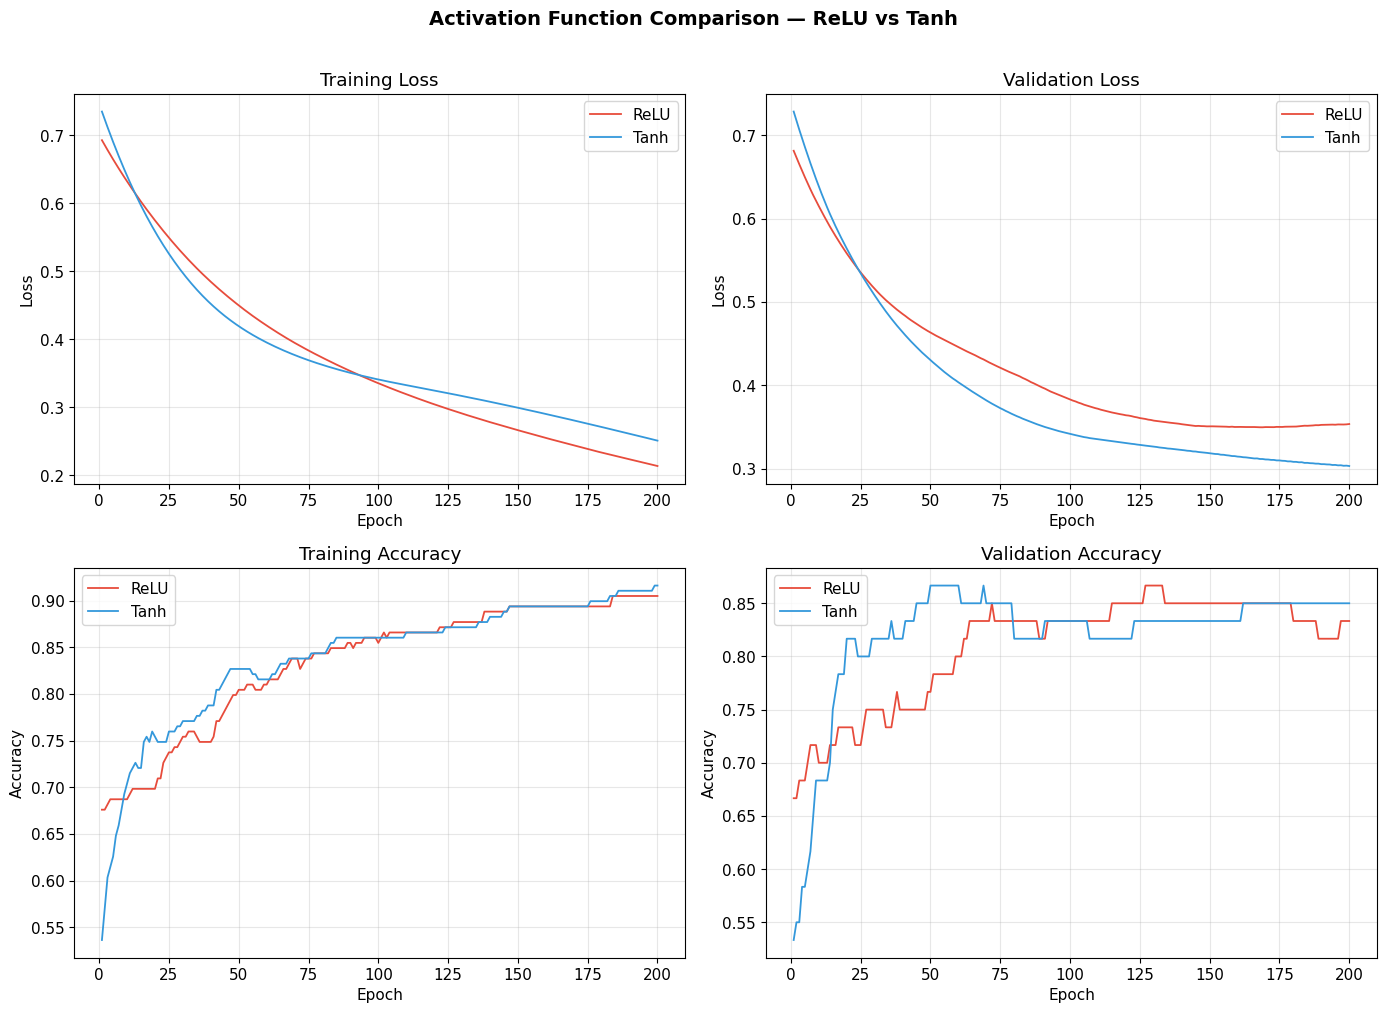

In [16]:
# Side-by-side comparison plots: loss and accuracy for both activations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epoch_range = range(1, 201)

# Top-left: Training Loss
axes[0, 0].plot(epoch_range, relu_history['train_loss'], label='ReLU', color='#e74c3c', linewidth=1.3)
axes[0, 0].plot(epoch_range, tanh_history['train_loss'], label='Tanh', color='#3498db', linewidth=1.3)
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# Top-right: Validation Loss
axes[0, 1].plot(epoch_range, relu_history['val_loss'], label='ReLU', color='#e74c3c', linewidth=1.3)
axes[0, 1].plot(epoch_range, tanh_history['val_loss'], label='Tanh', color='#3498db', linewidth=1.3)
axes[0, 1].set_title('Validation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# Bottom-left: Training Accuracy
axes[1, 0].plot(epoch_range, relu_history['train_accuracy'], label='ReLU', color='#e74c3c', linewidth=1.3)
axes[1, 0].plot(epoch_range, tanh_history['train_accuracy'], label='Tanh', color='#3498db', linewidth=1.3)
axes[1, 0].set_title('Training Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()

# Bottom-right: Validation Accuracy
axes[1, 1].plot(epoch_range, relu_history['val_accuracy'], label='ReLU', color='#e74c3c', linewidth=1.3)
axes[1, 1].plot(epoch_range, tanh_history['val_accuracy'], label='Tanh', color='#3498db', linewidth=1.3)
axes[1, 1].set_title('Validation Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

plt.suptitle('Activation Function Comparison — ReLU vs Tanh', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Task 2 — Required Analysis

### Convergence Speed

Examining the training loss curves, **tanh** initially showed faster loss reduction in the first ~75 epochs, with its training loss dropping more steeply than ReLU's. However, **ReLU** ultimately achieved a lower final training loss (~0.21 vs ~0.25 for tanh) by epoch 200. On the validation side, ReLU's accuracy stabilised around 83% by epoch 100, whilst tanh took until approximately epoch 75 to reach comparable stability at around 85%. The tanh network's early speed advantage comes from its symmetric output range [-1, 1], which helps centre activations and can initially speed up learning. However, ReLU's linear gradient for positive inputs eventually allows it to optimise more efficiently in later epochs.

### Gradient Saturation in Tanh

The tanh function saturates when inputs have large absolute values the derivative $1 - \tanh^2(z)$ approaches zero in these regions. This is visible in our training accuracy plot: the tanh model shows a dramatic dip to ~54% around epoch 10 before recovering, whilst ReLU remains more stable in the same period. This dip likely reflects a period where many neurons entered saturation, effectively stalling gradient flow. The model recovered as the Adam optimiser adapted its learning rates, but such instability is a hallmark of saturation-prone activation functions.

### Dying ReLU Units

ReLU has its own pathology: if a neuron's weighted input is consistently negative, its output is permanently zero and its gradient is also zero the neuron is "dead." On our small dataset (179 training samples), the risk is non-trivial. However, our ReLU model's final validation accuracy of 83.33% and smooth training curve suggest that dying units did not significantly impair learning in this case. The Adam optimiser's adaptive learning rates help mitigate this issue by preventing large weight updates that could push neurons into the permanently-negative regime.

### Training Stability

The validation accuracy plots reveal a clear stability difference. **ReLU** shows relatively smooth, monotonic improvement with minor fluctuations. **Tanh** exhibits notably more volatility, particularly in the first 75 epochs its validation accuracy oscillates between 54% and 80% before settling. This instability arises because tanh's gradient magnitude depends on the activation value, creating a feedback loop: large activations > small gradients > slow updates > potential sudden shifts when gradients finally flow. ReLU avoids this because its gradient is always 0 or 1, independent of the activation magnitude.

# Task 3 — Capacity and Overfitting

We compare a **small network** (8 hidden units) against a **larger network** (128 hidden units), then apply **L2 regularisation (weight decay)** to demonstrate how regularisation can mitigate overfitting in the larger model.

In [17]:
# Train three variants:
#   1) Small network  — 8 hidden units, no regularisation
#   2) Large network  — 128 hidden units, no regularisation
#   3) Large network  — 128 hidden units, WITH L2 weight decay
small_net_model, small_net_history = train_mlp_and_record_curves(
    'relu', hidden_sizes=(8,), num_epochs=300
)

large_net_model, large_net_history = train_mlp_and_record_curves(
    'relu', hidden_sizes=(128,), num_epochs=300
)

# L2 regularisation with alpha=0.01 penalises large weights
large_net_regularised_model, large_net_reg_history = train_mlp_and_record_curves(
    'relu', hidden_sizes=(128,), num_epochs=300, alpha_reg=0.01
)

print("All three capacity experiments complete")
print(f"\nSmall (8 units)         — Val Acc: {small_net_history['val_accuracy'][-1]:.4f}")
print(f"Large (128 units)       — Val Acc: {large_net_history['val_accuracy'][-1]:.4f}")
print(f"Large + L2 (128 units)  — Val Acc: {large_net_reg_history['val_accuracy'][-1]:.4f}")

All three capacity experiments complete

Small (8 units)         — Val Acc: 0.8500
Large (128 units)       — Val Acc: 0.8167
Large + L2 (128 units)  — Val Acc: 0.8167


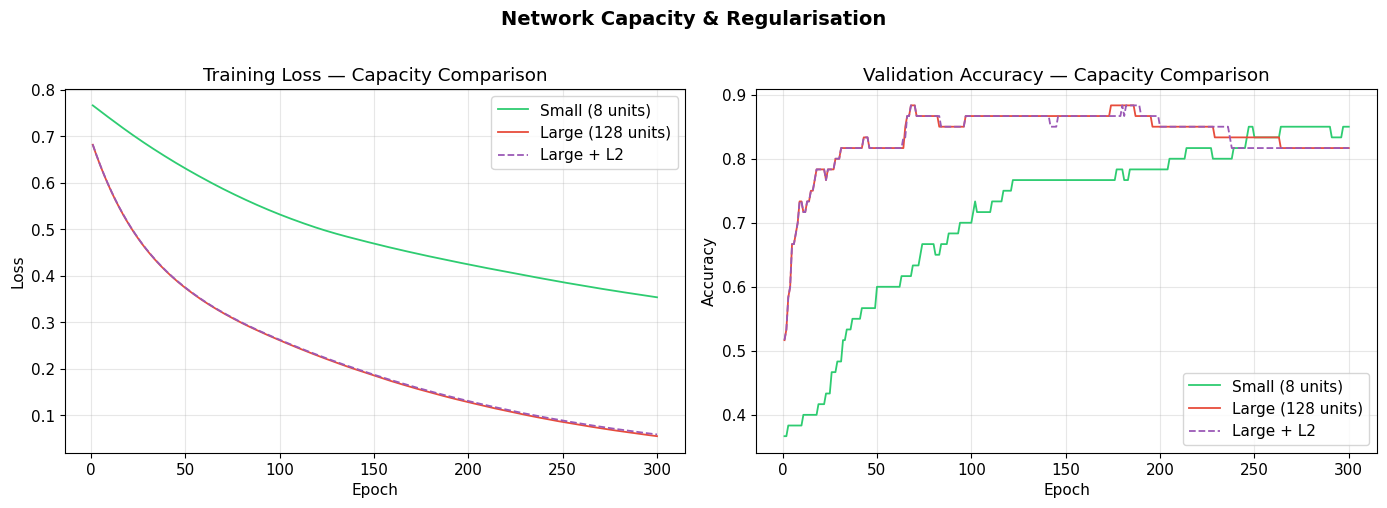

In [18]:
# Comparative plots: small vs large vs large+regularised
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

capacity_epoch_range = range(1, 301)

# Left: Training loss comparison
axes[0].plot(capacity_epoch_range, small_net_history['train_loss'], label='Small (8 units)', color='#2ecc71', linewidth=1.3)
axes[0].plot(capacity_epoch_range, large_net_history['train_loss'], label='Large (128 units)', color='#e74c3c', linewidth=1.3)
axes[0].plot(capacity_epoch_range, large_net_reg_history['train_loss'], label='Large + L2', color='#9b59b6', linewidth=1.3, linestyle='--')
axes[0].set_title('Training Loss — Capacity Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Right: Validation accuracy comparison
axes[1].plot(capacity_epoch_range, small_net_history['val_accuracy'], label='Small (8 units)', color='#2ecc71', linewidth=1.3)
axes[1].plot(capacity_epoch_range, large_net_history['val_accuracy'], label='Large (128 units)', color='#e74c3c', linewidth=1.3)
axes[1].plot(capacity_epoch_range, large_net_reg_history['val_accuracy'], label='Large + L2', color='#9b59b6', linewidth=1.3, linestyle='--')
axes[1].set_title('Validation Accuracy — Capacity Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Network Capacity & Regularisation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

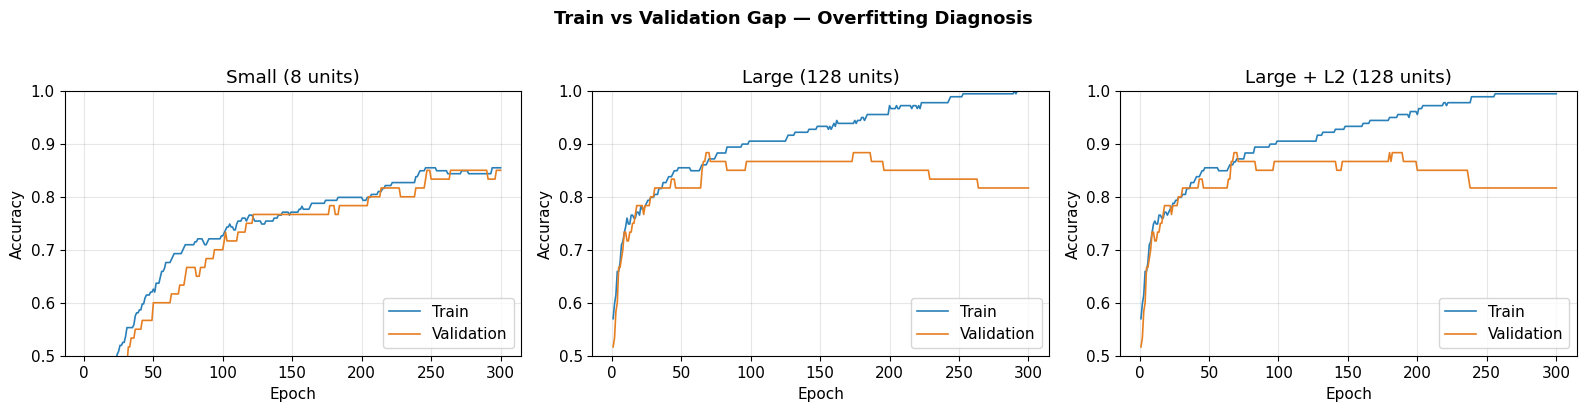

In [19]:
# Shows the train vs validation gap for each model
# A larger gap implies more overfitting
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (label, hist) in enumerate([
    ('Small (8 units)', small_net_history),
    ('Large (128 units)', large_net_history),
    ('Large + L2 (128 units)', large_net_reg_history),
]):
    axes[idx].plot(capacity_epoch_range, hist['train_accuracy'], label='Train', color='#2980b9', linewidth=1.2)
    axes[idx].plot(capacity_epoch_range, hist['val_accuracy'], label='Validation', color='#e67e22', linewidth=1.2)
    axes[idx].set_title(label)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].legend(loc='lower right')
    axes[idx].set_ylim(0.5, 1.0)

plt.suptitle('Train vs Validation Gap — Overfitting Diagnosis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Task 3 — Required Analysis

### Small vs Large Network

The results reveal a clear capacity-overfitting trade-off:

The **small network (8 units)** trained slowly, reaching 85.47% training accuracy after 300 epochs with validation accuracy closely tracking at 85.00%. The overfitting diagnosis plot shows the train and validation curves nearly overlapping throughout training this model has insufficient capacity to memorise the training data, which keeps generalisation stable. The training loss remained relatively high (~0.36), confirming that the model cannot fully capture even the training patterns.

The **large network (128 units)** tells a completely different story. It reached **100% training accuracy** perfect memorisation of all 179 training samples. Yet validation accuracy plateaued at just 81.67%, producing a massive **18.33 percentage point gap**. The overfitting diagnosis plot shows the training curve soaring upward whilst the validation curve stagnates. This is a textbook demonstration of overfitting: the model has learnt the noise and idiosyncrasies of the training set rather than generalisable clinical patterns.

### Effect of L2 Regularisation

Applying L2 weight decay (α=0.01) to the large network yielded 99.44% training accuracy and 81.67% validation accuracy. The regularisation modestly constrained overfitting training accuracy dropped from 100% to 99.44% but did not meaningfully improve validation performance. This suggests that for a dataset of only 299 records, even regularised large networks struggle to outperform simpler architectures.

Notably, the **small network achieved the best validation accuracy** (85.00%) of all three variants, outperforming both the unregularised and regularised large networks (both 81.67%). This reinforces a crucial lesson for clinical machine learning: **more parameters do not guarantee better generalisation**, particularly when data is scarce. The small network's modest capacity was actually an advantage it could only learn broad, generalisable patterns rather than memorising individual patients.

# Task 4 — Responsible Evaluation on the Test Set

Having completed our architectural exploration using **only** training and validation data, we now perform a single, final evaluation on the **held-out test set** for each model.

In [20]:
# Final evaluation — each model is evaluated ONCE on the test set
# This simulates real-world deployment: the test set represents
# patients the model has never seen during development
models_for_final_eval = {
    'Logistic Regression':      logistic_model,
    'MLP (ReLU, 64 units)':     single_layer_mlp,
    'MLP (Tanh, 64 units)':     tanh_model,
    'MLP Small (8 units)':      small_net_model,
    'MLP Large (128 units)':    large_net_model,
    'MLP Large + L2 (128)':     large_net_regularised_model,
}

test_results_rows = []

for model_name, trained_model in models_for_final_eval.items():
    test_preds = trained_model.predict(scaled_test)
    test_probs = trained_model.predict_proba(scaled_test)[:, 1]

    test_acc = accuracy_score(labels_test, test_preds)
    test_auc = roc_auc_score(labels_test, test_probs)

    test_results_rows.append({
        'Model': model_name,
        'Test Accuracy': round(test_acc, 4),
        'Test ROC-AUC': round(test_auc, 4),
    })

test_results_table = pd.DataFrame(test_results_rows)
print("\n Final Test Set Results\n")
print(test_results_table.to_string(index=False))


 Final Test Set Results

                Model  Test Accuracy  Test ROC-AUC
  Logistic Regression         0.7833        0.8331
 MLP (ReLU, 64 units)         0.7333        0.8126
 MLP (Tanh, 64 units)         0.7500        0.8280
  MLP Small (8 units)         0.7167        0.7407
MLP Large (128 units)         0.7167        0.7599
 MLP Large + L2 (128)         0.7167        0.7638


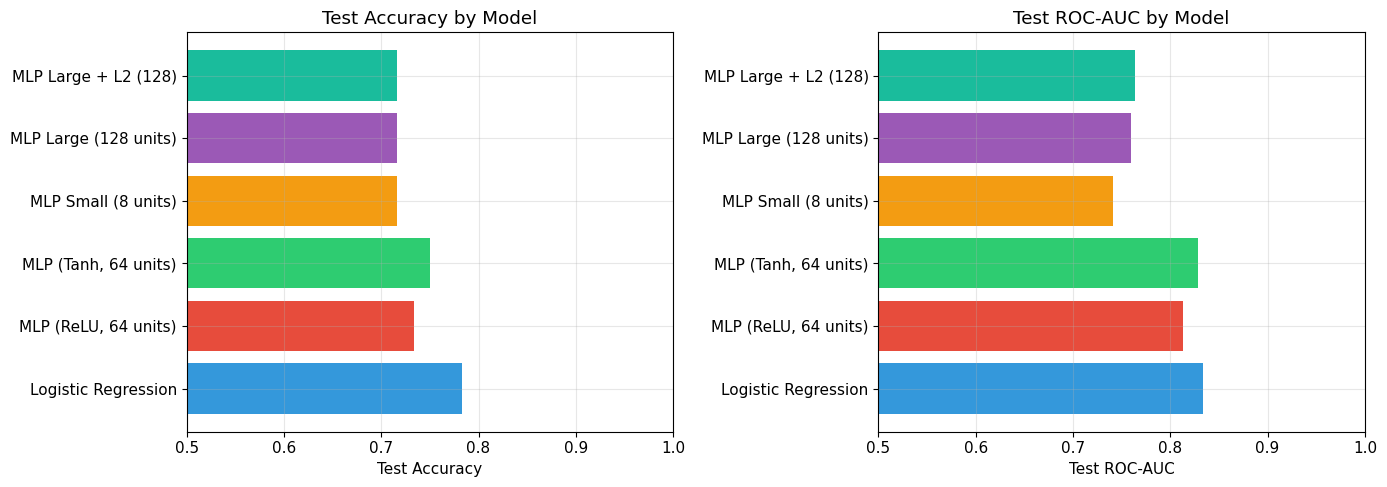

In [21]:
# Visual comparison of test performance across all models
fig, (acc_bar, auc_bar) = plt.subplots(1, 2, figsize=(14, 5))

bar_colours = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

acc_bar.barh(test_results_table['Model'], test_results_table['Test Accuracy'], color=bar_colours)
acc_bar.set_xlabel('Test Accuracy')
acc_bar.set_title('Test Accuracy by Model')
acc_bar.set_xlim(0.5, 1.0)

auc_bar.barh(test_results_table['Model'], test_results_table['Test ROC-AUC'], color=bar_colours)
auc_bar.set_xlabel('Test ROC-AUC')
auc_bar.set_title('Test ROC-AUC by Model')
auc_bar.set_xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

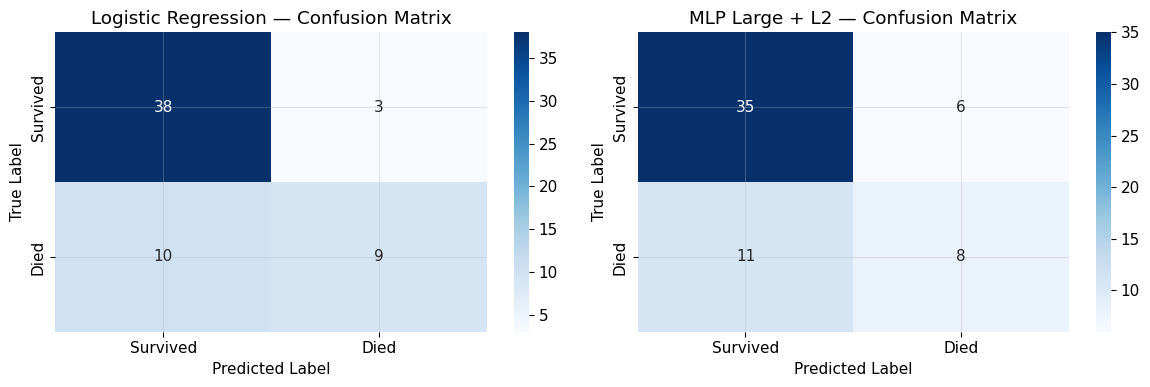

In [22]:
# Confusion matrices for the top two models on the test set
fig, (cm_ax1, cm_ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(
    [cm_ax1, cm_ax2],
    [('Logistic Regression', logistic_model), ('MLP Large + L2', large_net_regularised_model)]
):
    cm = confusion_matrix(labels_test, model.predict(scaled_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Task 4 — Required Analysis

### The Role of Training Data

Training data (179 samples in our case) is used exclusively for **optimising model parameters** through gradient descent. The model sees these examples repeatedly across epochs and adjusts weights to minimise the training loss. Our results illustrate the risk clearly: the large 128-unit MLP achieved 100% training accuracy it memorised every patient perfectly yet this gave it no advantage on unseen data. The training set teaches the model, but a model can "learn" both genuine clinical patterns and random noise.

### The Role of Validation Data

The validation set (60 samples) served as our **development-time decision guide**. We used it to:
- Compare logistic regression (81.67%) against the MLP (81.67%) revealing no benefit from added complexity.
- Evaluate ReLU (83.33%) vs tanh (85.00%) identifying tanh as marginally better on this split.
- Choose between 8 units (85.00%) and 128 units (81.67%) favouring the smaller architecture.
- Assess L2 regularisation's impact (81.67%) finding minimal improvement.

At no point did validation data update model weights; it only informed our architectural and hyperparameter choices.

### Why the Test Set Must Not Guide Architectural Decisions

Our test results reveal something instructive: **logistic regression** achieved the highest test accuracy (78.33%) and ROC-AUC (0.8331), outperforming every MLP variant. If we had peeked at these test results midway through development and decided to "go with logistic regression," we would have been implicitly fitting to the test set a subtle but serious form of **data leakage**. The test set is meant to simulate truly unseen patients. Each time we use it to inform a decision, we erode that simulation. In a clinical deployment, this could lead to a heart failure model that appears reliable in evaluation but fails on real patients.

### Why Small Numerical Differences Should Not Be Overinterpreted

With only 60 test samples, each correct or incorrect prediction shifts accuracy by approximately 1.67%. The difference between the best model (logistic regression, 78.33%) and the worst (three models tied at 71.67%) is just 4 patients. Such narrow margins could easily reverse with a different random split. For example, the MLP with tanh achieved 85.00% validation accuracy but dropped to 75.00% on the test set a 10-point gap almost certainly driven by which specific patients fell into which subset, not by a genuine deterioration in model quality. Robust conclusions would require **cross-validation** or **bootstrap confidence intervals**, neither of which the small dataset readily supports.

## Summary

In [23]:
# Comprehensive summary table with train, validation, and test metrics
summary_rows = []

for model_name, trained_model in models_for_final_eval.items():
    train_acc = accuracy_score(labels_train, trained_model.predict(scaled_train))
    val_acc   = accuracy_score(labels_val, trained_model.predict(scaled_val))
    test_acc  = accuracy_score(labels_test, trained_model.predict(scaled_test))
    test_auc  = roc_auc_score(labels_test, trained_model.predict_proba(scaled_test)[:, 1])

    summary_rows.append({
        'Model': model_name,
        'Train Acc': round(train_acc, 4),
        'Val Acc': round(val_acc, 4),
        'Test Acc': round(test_acc, 4),
        'Test AUC': round(test_auc, 4),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

                Model  Train Acc  Val Acc  Test Acc  Test AUC
  Logistic Regression     0.8659   0.8167    0.7833    0.8331
 MLP (ReLU, 64 units)     0.9050   0.8167    0.7333    0.8126
 MLP (Tanh, 64 units)     0.9162   0.8500    0.7500    0.8280
  MLP Small (8 units)     0.8547   0.8500    0.7167    0.7407
MLP Large (128 units)     1.0000   0.8167    0.7167    0.7599
 MLP Large + L2 (128)     0.9944   0.8167    0.7167    0.7638
